In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.process import RFQ

In [2]:
def scurve(delta, alpha, beta, delta_0):
    return 1 / (1 + torch.exp(alpha + beta / delta_0 * delta))


def utility(
    ask_delta,
    bid_delta,
    q,
    z,
    ask_lamda,
    bid_lamda,
    gamma,
    alpha,
    beta,
    delta_0,
    kappa,
    delta_t,
    sigma,
):
    t = ask_delta.shape[1]

    res = 0
    for i in range(t):
        res += (
            z
            * ask_delta[:, i]
            * ask_lamda[:, i]
            * scurve(ask_delta[:, i], alpha, beta, delta_0)
            + z
            * bid_delta[:, i]
            * bid_lamda[:, i]
            * scurve(bid_delta[:, i], alpha, beta, delta_0)
        ) + (
            + kappa * (ask_lamda[:, i] - bid_lamda[:, i]) * q[:, i]
            - gamma / 2 * q[:, i] ** 2 * sigma**2
        ) * delta_t
    return torch.mean(res)

In [3]:
from src.model import *


def fair_price(
    rfq, gamma, delta_0, z, alpha, beta, batch_size=100, epoch=100, lr=0.0001, device = torch.device('cpu')
):
    ask_models = []
    bid_models = []
    i = 0
    n_model = rfq.num_time_interval




    while i <= n_model-1:
        f= False

        model = RL_Net(4,1,[10,10,20,10]).to(device)



        model.apply(weights_init_uniform_rule)
        ask_models.append(model)

        model = RL_Net(4 ,1,[10,10,20,10]).to(device)



        model.apply(weights_init_uniform_rule)
        bid_models.append(model)
        i += 1



        
    optimizer_bid= torch.optim.Adam((par for model in bid_models
                    for par in model.parameters()),
                    lr=lr, betas=(0.9, 0.99))
    optimizer_ask= torch.optim.Adam((par for model in ask_models
                    for par in model.parameters()),
                    lr=lr, betas=(0.9, 0.99))




    for _ in range(epoch):
      ask_lamda, bid_lamda,prices,_ = rfq.sample(batch_size)
      ask_lamda = torch.tensor(ask_lamda).to(torch.float32)
      bid_lamda = torch.tensor(bid_lamda).to(torch.float32)
      prices = torch.tensor(prices).to(torch.float32)
      q = torch.zeros((batch_size ,rfq.num_time_interval + 1))
      ask_delta = torch.zeros((batch_size ,rfq.num_time_interval))
      bid_delta = torch.zeros((batch_size ,rfq.num_time_interval))
      optimizer_ask.zero_grad()
      optimizer_bid.zero_grad()
      for t in range(rfq.num_time_interval):
          
          #q[:, t+1] = z*(bid_lamda[:,t] - ask_lamda[:,t]) 
          input = torch.cat((torch.ones((batch_size ,1 ))*t * rfq.delta_t ,q[:, t:t+1].detach()  , ask_lamda[:,t:t+1] , bid_lamda[:,t:t+1]), dim=1)
          ask_delta[:,t:t+1] = ask_models[t](input)
          bid_delta[:,t:t+1] = bid_models[t](input)
          q[:, t+1] = q[:, t] + z*(bid_lamda[:,t]*scurve(bid_delta[:,t],alpha , beta, delta_0) - ask_lamda[:,t]*scurve(ask_delta[:,t],alpha , beta, delta_0))


      loss = -1 * utility(ask_delta,bid_delta,q,z,ask_lamda, bid_lamda,gamma,alpha,beta,delta_0,rfq.k,rfq.delta_t,rfq.sigma)

      loss.backward()
      optimizer_ask.step()
      optimizer_bid.step()

      print(f"Loss: {-1 *round(loss.item(), 3)}")

In [4]:
basic = {'dim' : 1 , 'total_time' : 0.25 , 'num_time_interval': 90 }
specific = {'init':103.593 , 'sigma':0.1839 ,  'nls' :2 , 'lamdas' : np.array([10.83, 73.03]) /10, 'init_state':1,'k' : 2.29 , 'Q': np.array([
        [-14.01, 4.37, 4.37, 5.27],
        [19.32, -60.91, 12.54, 29.05],
        [19.32, 12.54, -60.91, 29.05],
        [23.67, 15.00, 15.00, -53.67],
    ]),
}

rfq = RFQ(basic, specific)
print(rfq)

RFQ:
{
dim: 
1, 

total_time: 
30, 

num_time_interval: 
30, 

delta_t: 
1.0, 

sqrt_delta_t: 
1.0, 

y_init: 
None, 

n_liqiudity_state: 
2, 

x_init: 
[103.593], 

lamda_initial_state: 
2, 

sigma: 
0.011584611097732815, 

k: 
2.29, 

lamdas: 
[1.083 7.303], 

Q: 
[[-14.01   4.37   4.37   5.27]
 [ 19.32 -60.91  12.54  29.05]
 [ 19.32  12.54 -60.91  29.05]
 [ 23.67  15.    15.   -53.67]]
}


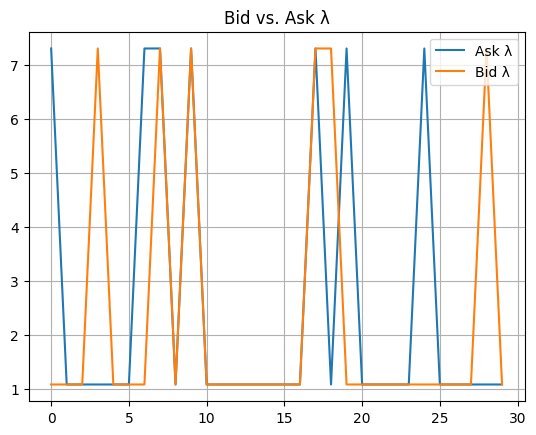

In [5]:
ask_lamda, bid_lambda, x_sample , _ = rfq.sample(1)
ask_lambda, bid_lambda, x_sample = ask_lamda[0], bid_lambda[0], x_sample[0]

x = np.arange(ask_lambda.shape[0])
plt.clf()
plt.plot(x, ask_lambda.tolist(), label="Ask λ")
plt.plot(x, bid_lambda.tolist(), label="Bid λ")
plt.legend()
plt.grid()
plt.title("Bid vs. Ask λ")
plt.show()

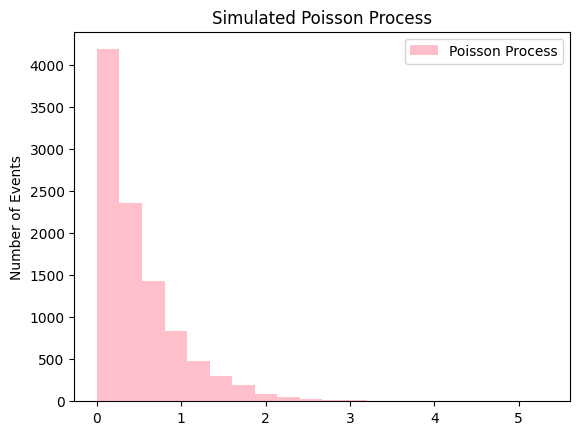

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
scale = 0.5  # Average rate of events per unit time
simulation_time = 10000  # Total simulation time

# Simulate a Poisson process
arrival_times = np.random.exponential(scale=scale, size=simulation_time)

# Plot the results
plt.hist(arrival_times, label='Poisson Process', color="pink", bins=20)
plt.ylabel('Number of Events')
plt.title('Simulated Poisson Process')
plt.legend()
plt.show()

In [8]:
gamma = 0.0005
z = 1

# s-curve parameters from page 27 of Bergault paper
delta_0 = 0.09
alpha = -0.7
beta = 3.1

fair_price(rfq, gamma, delta_0, z, alpha, beta)

Loss: -34.271
Loss: -38.816
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Loss: nan
Lo